## 1. 탐색적 데이터 분석(EDA) 및 전처리 파이프라인 구현

### [문항 1-1] 데이터 구조 탐색 및 기초 분석

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetes.csv') 

print("[데이터 구조]")
print("=" * 70)
print("행렬 크기:",df.shape)
print("컬럼별 자료형 및 결측치 개수 확인:")
df.info()

[데이터 구조]
행렬 크기: (768, 9)
컬럼별 자료형 및 결측치 개수 확인:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
print("=" * 70)
print("컬럼별 통계량 확인:\n",df.describe())

컬럼별 통계량 확인:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000     

- `Insulin`과 `SkinThickness`는 max(최대값)가 50%, 75%값보다 크게 나타나 극단값이 존재할 가능성을 확인함.
- 또한, describe()로 이상치가 있는지 확인하던 도중 [`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`] 컬럼에서 min 값이 0으로 들어가 있음을 확인
- 위 컬럼들은 값이 0이면 실제 생리학적으로 의미가 없거나, 매우 비현실적인 값임. (사람의 혈압이 0일 수는 없음)
- `Pregnancies`(임신 횟수)나 `Outcome`(당뇨 여부)는 0이 정상적인 값임.
- 따라서, 위 5개 컬럼에서 0은 결측치로서 기록된 값으로 판단함.

In [4]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] # 5개 컬럼을 zero_cols로 묶어 컬럼벌 0값 확인

print("상위 15개 데이터의 0값 확인:")
print(df[zero_cols].head(15))

print("컬럼별 0값(결측치) 개수:")
print((df[zero_cols] == 0).sum())

상위 15개 데이터의 0값 확인:
    Glucose  BloodPressure  SkinThickness  Insulin   BMI
0       148             72             35        0  33.6
1        85             66             29        0  26.6
2       183             64              0        0  23.3
3        89             66             23       94  28.1
4       137             40             35      168  43.1
5       116             74              0        0  25.6
6        78             50             32       88  31.0
7       115              0              0        0  35.3
8       197             70             45      543  30.5
9       125             96              0        0   0.0
10      110             92              0        0  37.6
11      168             74              0        0  38.0
12      139             80              0        0  27.1
13      189             60             23      846  30.1
14      166             72             19      175  25.8
컬럼별 0값(결측치) 개수:
Glucose            5
BloodPressure     35
SkinThickne

### [문항 1-2] 전처리 파이프라인 구축

#### 분석된 결과를 바탕으로 결측치 처리

- 0을 NaN으로 바꾸는 것을 결측치 대체 방식으로 선택함

In [5]:
# 결측치 및 이상치 처리
# 0으로 입력된 결측치를 NaN으로 바꾼다
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
print("NaN으로 변경된 값 확인:")
print(df.isna().sum())

NaN으로 변경된 값 확인:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


#### 데이터 스케일러(StandardScaler) 적용 및 선택 근거
- 머신러닝 학습 전, 변수마다 값의 범위와 분산이 다르므로 스케일 차이를 줄이기 위해 StandardScaler를 이용하여 평균 0과 표준편차 1을 기준으로 데이터를 표준화한다.
- 데이터 누수를 방지하기 위해 Train/Test 데이터 분리를 먼저 수행하였다.
- 이후 결측치가 0으로 입력된 컬럼을 평균값 혹은 중앙값으로 대체함 (이상치가 있는 Insulin, SkinThickness 에서만 중앙값을 적용)
- 결측치 대체는 Train 데이터에서만 계산하고, 해당 값을 Train과 Test 데이터에 동일하게 적용함
- 이후 StandardScaler에서 Train 데이터에는 fit을 적용하였고, Test 데이터에서는 transform을 적용함.

**X에는 범주형 변수가 존재하지 않으므로, 범주형 변수 인코딩을 수행하지 않음**

In [6]:
# X, y 분리
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train, Test 분리 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train 데이터 통계량으로 결측치 처리
# Glucose, BloodPressure, BMI → 평균값을 사용하여 결측치 대체
for col in ['Glucose', 'BloodPressure', 'BMI']:
    mean_value = X_train[col].mean()
    X_train[col] = X_train[col].fillna(mean_value)
    X_test[col] = X_test[col].fillna(mean_value)

# Insulin, SkinThickness → 이상치의 영향을 줄이기 위해 중앙값으로 결측치 대체
for col in ['Insulin', 'SkinThickness']:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

# 데이터 스케일링
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("전처리 완료")
print("X_train 데이터 개수:", X_train_scaled.shape)
print("X_test 데이터 개수:", X_test_scaled.shape)

전처리 완료
X_train 데이터 개수: (614, 8)
X_test 데이터 개수: (154, 8)


### [문항 1-2] 데이터 시각화 및 인사이트 도출

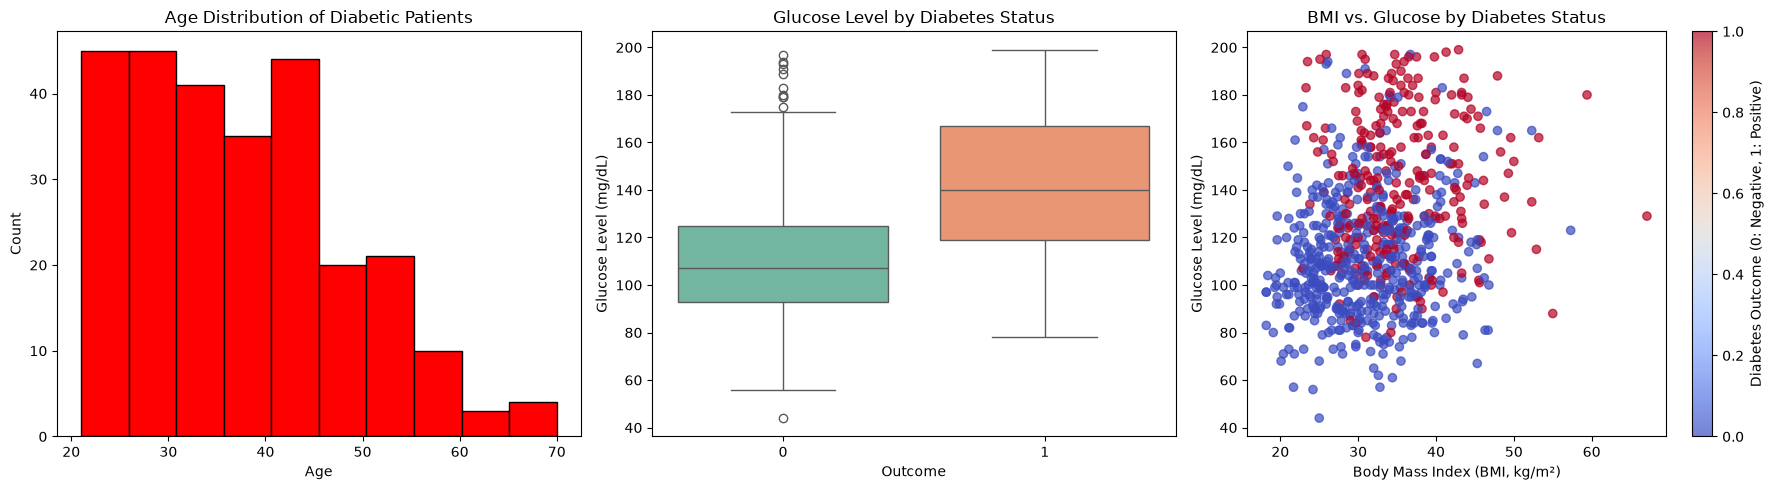

In [7]:
# 3개 그래프(히스토그램, 박스플롯, 산점도)를 위한 도화지와 액자 준비
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 당뇨가 있는 사람들만 모으기 
df_diabetes = df[df['Outcome'] == 1]

# 히스토그램: 당뇨환자 연령 분포 
axes[0].hist(df_diabetes['Age'], bins=10, color='red', edgecolor='black')
axes[0].set_title('Age Distribution of Diabetic Patients')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# 박스플롯: 당뇨 여부에 따른 혈당수준 분포 비교
sns.boxplot(x='Outcome', y='Glucose', hue='Outcome', data=df, ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Glucose Level by Diabetes Status')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Glucose Level (mg/dL)')

# 산점도: 비만과 혈당 및 당뇨의 관계
scatter = axes[2].scatter(
    df['BMI'],
    df['Glucose'],
    c=df['Outcome'],
    cmap='coolwarm',
    alpha=0.7
)
axes[2].set_title('BMI vs. Glucose by Diabetes Status')
axes[2].set_xlabel('Body Mass Index (BMI, kg/m²)')
axes[2].set_ylabel('Glucose Level (mg/dL)')

fig.colorbar(scatter, ax=axes[2], label='Diabetes Outcome (0: Negative, 1: Positive)')

plt.tight_layout()
plt.show()

[통계 인사이트]

1. 히스토그램: 당뇨 환자 연령 분포
- 당뇨 환자는 20~40대 비중이 가장 높으며, 50대부터 점차 감소함.

2. 박스플롯: 당뇨 여부에 따른 혈당 분포 비교
- 당뇨 그룹(Outcome=1)의 혈당 중앙값은 약 140 mg/dL로, 비당뇨 그룹(Outcome=0)의 약 107 mg/dL보다 높게 나타남.
- 당뇨 그룹의 전반적 혈당 분포가 비당뇨 그룹보다 높은 수준에 위치함.
- 비당뇨 그룹에서 약 180~195 mg/dL의 높은 혈당값이 이상치로 나타난 반면, 당뇨 그룹은 혈당 범위가 약 80~200 mg/dL로 높은 혈당값이 이상치가 아닌 일반 분포에 포함되어 있음.
- 따라서, 혈당이 당뇨 여부와 관련성이 높은 변수임을 확인함.

3. 산점도: 비만과 혈당 및 당뇨의 관계 표현
- 당뇨 환자 그룹에서 높은 혈당값을 가진 데이터가 비당뇨 환자에 비해 상대적으로 많이 나타남.
- BMI와 혈당의 뚜렷한 선형관계는 나타나지 않음. 
- Glucose가 증가할수록 당뇨 환자의 비율이 높아지는 경향이 나타남.
- Glucose는 BMI보다 당뇨 여부와의 관련성이 더 뚜렷하게 관찰됨.

## 2. 머신러닝 모델 학습, 과적합 점검 및 하이퍼파라미터 튜닝

### 필수 구현 내용

[문항 2-1] 회귀 및 분류 모델 학습과 성능 측정

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Logistic Regression 모델 생성 및 학습
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# test 데이터 예측
y_pred = model.predict(X_test_scaled)

# 모델 성능 측정
accuracy = accuracy_score(y_test, y_pred) 
f1 = f1_score(y_test, y_pred) 

print("Outcome 클래스 분포:")
print(df['Outcome'].value_counts(normalize=True))

print("[Logistic Regression 이진분류 성능]")
print(f"최종 테스트 정확도: {accuracy:.4f}") 
print(f"테스트 데이터 F1-score: {f1:.4f}") 

Outcome 클래스 분포:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64
[Logistic Regression 이진분류 성능]
최종 테스트 정확도: 0.7078
테스트 데이터 F1-score: 0.5455


### 심화 구현 내용

#### [문항 2-2 결과물]: 평가지표 선택 이유, 모델 예측 성능에 대한 분석 및 오류 원인 해석 내용 (마크다운 셀)

[평가지표 선정 근거]
- 본 과제에서는 당뇨 여부(Outcome)을 0과 1로 분류하는 이진분류 모델이므로 Logistic Regression을 사용함.
- 모델의 전체적인 분류 정확도를 평가하기 위해, 전체 데이터 중 올바르게 분류한 데이터의 비율을 나타내는 Accuracy를 사용함.
- Outcome의 클래스 분포를 확인한 결과, 비당뇨 그룹(0)은 약 65.1%, 당뇨환자 그룹(1)는 약 34.9%로 비당뇨 데이터에서 불균형이 존재함.
- 따라서, 당뇨환자(Outcome=1)에 대한 Precision과 Recall을 함께 고려하는 F1-score을 함께 사용함.

[예측 결과 및 오류 원인 해석]
- 최종 테스트 정확도 (Accuracy): 0.7078 -> 모델이 전체 테스트 데이터의 약 70.78%를 올바르게 분류했음.
- F1-score: 0.5455 -> Accuracy에 비해 F1-score가 상대적으로 낮게 나타났으며, 이는 모델의 당뇨환자를 분류하는 성능이 상대적으로 부족함을 의미함.
- Outcome 클래스 분포가 불균형하기 때문에, 상대적으로 모델이 데이터가 많은 비당뇨 그룹을 더 잘 학습했을 가능성이 있음.
- 5개 컬럼에서 0으로 기록된 값을 결측치로 처리하고, 이를 평균값 혹은 중앙값으로 대체하는 과정에서 실제 관측값의 분포와 차이가 발생하여 일부 정보가 손실되고 모델 예측 성능에 영향을 주었을 가능성이 있음.
- 특히, Insulin과 SkinThickness에서는 다른 컬럼에 비해 결측치가 많이 존재했으며, 중앙값으로 대체된 데이터의 비중이 높아 원래 변수의 분포와 개별 데이터의 특성이 충분히 보존되지 않았을 가능성이 있음.

#### [문항 2-3 결과물]: 규제, 교차 검증, 튜닝이 반영된 모델 개선 코드 및 개선 전후의 성능 지표 비교 테이블과 기법별 효과 요약 글

In [16]:
# [문항 2-3 코드]
# 규제, 교차 검증, 하이퍼파라미터 튜닝을 통한 성능 개선
from sklearn.model_selection import GridSearchCV

# 1. 기존 모델 과적합 점검: 기존 모델의 Train, Test 성능을 비교
y_train_pred = model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("[기존 모델 과적합 점검]")
print(f"훈련 데이터 정확도: {train_accuracy:.4f}") 
print(f"테스트 데이터 정확도: {accuracy:.4f}") 

print(f"훈련 데이터 F1-score: {train_f1:.4f}") 
print(f"테스트 데이터 F1-score: {f1:.4f}") 

[기존 모델 과적합 점검]
훈련 데이터 정확도: 0.7980
테스트 데이터 정확도: 0.7078
훈련 데이터 F1-score: 0.6737
테스트 데이터 F1-score: 0.5455


In [11]:
# 2. L2 규제 - 기존 모델 기준으로 C 후보를 교차검증하여 최적값 탐색
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# 3. 5-Fold 교차검증 + 하이퍼파라미터 튜닝
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5, # 교차검증
    scoring='f1' # 최적 모델 선택 기준
)

# 4. 훈련 데이터에서 최적 하이퍼파라미터 탐색
grid_search.fit(X_train_scaled, y_train)

print("훈련 데이터 최적 하이퍼파라미터 확인:", grid_search.best_params_)
print(f"최적의 교차검증 F1-score: {grid_search.best_score_:.4f}")

# 5. 최적 모델의 테스트 성능 평가
best_model = grid_search.best_estimator_ # 교차검증 결과 가장 성능이 좋았던 최적 모델 가져오기

y_tuned_pred = best_model.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test, y_tuned_pred)
tuned_f1 = f1_score(y_test, y_tuned_pred)

훈련 데이터 최적 하이퍼파라미터 확인: {'C': 1}
최적의 교차검증 F1-score: 0.6539


In [12]:
# 6. 기존 모델과 튜닝 모델 성능 비교 테이블
comparison = pd.DataFrame({
    'Model': [
        '기존 모델',
        '튜닝 모델'
    ],
    'Accuracy': [
        accuracy,
        tuned_accuracy
    ],
    'F1-score': [
        f1,
        tuned_f1
    ]
})

print("\n[모델 개선 전후 성능 비교 테이블]")
print(comparison)


[모델 개선 전후 성능 비교 테이블]
   Model  Accuracy  F1-score
0  기존 모델  0.707792  0.545455
1  튜닝 모델  0.707792  0.545455


[기법별 효과 요약]

1. L2 규제
   - Logistic Regression의 기본 규제인 L2 규제를 사용했고, 규제 강도를 조절하는 하이퍼파라미터 `C`를 [0.01, 0.1, 1, 10, 100]으로 설정하여 탐색함.
   - `C=1`이 최적값으로 선택되어, 기본 규제 강도는 탐색한 후보 중 `C=1`이 가장 적절한 것으로 확인함.

2. 5-Fold 교차검증(Cross-Validation)
   - 훈련 데이터를 5개의 Fold로 나누어 반복 학습 및 검증 수행
   - 교차검증을 통해 하나의 훈련/검증 데이터 분할 결과에만 의존하는 것이 아닌 모델의 일반화 성능을 보다 안정적으로 평가 가능함.
   - 교차검증 결과, 최고 평균 F1-score는 0.6539임을 확인함.

3. 하이퍼파라미터 튜닝(GridSearchCV)
   - 하이퍼파라미터 튜닝으로 여러 `C`후보를 5-Fold 교차검증하고, 최적의 F1-score를 탐색함(C=1).
   - 튜닝 모델의 테스트 정확도(Accuracy)는 0.707792, F1-score는 0.545455로 기존 모델과 동일하게 나타남.

[튜닝 전후 성능 비교 및 결론]
- 기존 모델: Accuracy 0.7078, F1-score 0.5455
- 튜닝 모델: Accuracy 0.7078, F1-score 0.5455
- 규제, 교차검증 및 하이퍼파라미터 튜닝 적용 이후에도 최종 테스트의 성능은 향상되지 않았음.
- 이는 하이퍼파라미터 튜닝을 통해 선택된 최적값 `C=1`이 기존 모델의 기본값과 동일했기 때문으로 볼 수 있음.
- 결론적으로는 튜닝을 통한 성능 향상보다는 교차검증을 통해 Logistic Regression의 기본값인 `C=1`이 가장 안정적인 설정임을 검증했음.

## 3. Hugging Face 사전 학습된 모델을 활용한 뉴스 기사 분류 및 추론

### 필수 구현 내용

Hugging Face 라이브러리를 활용하여 사전 학습된(Pre-trained) Gemma 모델과 토크나이저를 독립된 개발 환경 내에 그대로 로드하는 코드를 구현합니다.

In [13]:
# [문항 3-1] 사전 학습된 모델 및 토크나이저 로드
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM
import torch

# Mac GPU(MPS)를 사용할 수 있으면 MPS, 아니면 CPU 사용
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

# 사용할 Hugging Face 모델 식별자
gemma_identifier = "google/gemma-2b-it"

# 사전 학습된 토크나이저 로드
gemma_tokenizer = PreTrainedTokenizerFast.from_pretrained(gemma_identifier)

# 사전 학습된 모델 로드
gemma_model = AutoModelForCausalLM.from_pretrained(
    gemma_identifier,
    dtype=torch.float16 if device.type == "mps" else torch.float32
).to(device)

# 모델을 추론모드로 설정
gemma_model.eval()

# 로드 결과 확인
print("모델 및 토크나이저 로드 완료")
print("모델:", gemma_identifier)
print("모델 클래스:", gemma_model.__class__.__name__)
print("토크나이저 클래스:", gemma_tokenizer.__class__.__name__)
print("사용 장치:", device)

/Users/myungjilee/Desktop/Kant/projects/ml-final-pj-보관용/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 164/164 [00:06<00:00, 26.71it/s]


모델 및 토크나이저 로드 완료
모델: google/gemma-2b-it
모델 클래스: GemmaForCausalLM
토크나이저 클래스: TokenizersBackend
사용 장치: mps


In [32]:
# [문항 3-2] 문맥 내 학습(In-context Learning) 기반 뉴스 기사 분류 추론

# 입력 뉴스 정의
input_news = """ 
전 세계적인 흥행 돌풍을 일으키며 극장가를 뜨겁게 달군 영화 ‘오디세이’가 누적 관객 수 1,000만 명을 돌파했다.
영화관입장권 통합전산망에 따르면 ‘오디세이’는 개봉 33일째인 6일 오후 4시 누적 관객 1,000만 명을 넘어섰다. 2026년 개봉 외화 중 처음으로 천만 관객을 달성했으며, ‘아바타: 물의 길’ 이후 약 4년 만에 나온 천만 외화가 됐다.
크리스토퍼 놀란 감독은 ‘인터스텔라’에 이어 두 번째 천만 영화를 보유하게 됐다. 이로써 ‘어벤져스’ 시리즈의 루소 형제, ‘아바타’ 시리즈의 제임스 카메론, ‘겨울왕국’ 시리즈의 크리스 벅과 제니퍼 리에 이어 국내에서 복수의 천만 외화를 연출한 감독 명단에 이름을 올렸다.
"""

# Few-shot 예시가 포함된 프롬프트
classification_prompt = f"""
Classify the news article into exactly one category:
Politics, Economy, Society, Sports, Technology, Entertainment.

Return only the category name.

Examples:

Article: The government announced a new national security bill.
Category: Politics

Article: The company's annual revenue and profit increased.
Category: Economy

Article: Residents were evacuated because of heavy flooding.
Category: Society

Article: The baseball team won the championship.
Category: Sports

Article: Researchers developed a new artificial intelligence chip.
Category: Technology

Article: A famous actor won an award for his performance in a movie.
Category: Entertainment

Now classify this article:

Article: {input_news.strip()}
Cateogry:
"""

# Gemma 대화 형식으로 프롬프트 변환
messages = [
    {
        "role": "user",
        "content": classification_prompt
    }
]

# 일반 문자열 프롬프트를 Gemma가 학습한 전용 채팅 템플릿 형식으로 변환
formatted_prompt = gemma_tokenizer.apply_chat_template(
    messages, # 변환할 대화 메시지
    tokenize=False, # 토큰화하지 않고 문자열로 변환
    add_generation_prompt=True # 모델의 답변 시작을 나타내는 형식 추가
)

# 채팅 형식으로 변환된 문자열을 모델이 처리가능한 숫자 형식으로 변환
inputs = gemma_tokenizer(
    formatted_prompt, # 토큰화할 프롬프트
    add_special_tokens = False,
    return_tensors="pt" # 결과를 pytorch tensor 형태로 변환
).to(device) # 입력 데이터를 mps로 이동

# 입력 토큰의 길이
input_length = inputs["input_ids"].shape[1]

# 별도의 가중치 학습 없이 추론 -> 기울기 비활성화
with torch.no_grad():
    # 입력 프롬프트 뒤에 이어질 답변 토큰 생성
    output_ids = gemma_model.generate( 
        **inputs, # input_ids와 attention_mask 전달
        max_new_tokens=50, # 새로 생성할 토큰을 최대 50개로 제한
        do_sample=False, # 무작위 추출 없이 가장 가능성 높은 토큰을 선택
        pad_token_id=gemma_tokenizer.eos_token_id, # 패딩 토큰이 없을 경우 종료 토큰 사용
        eos_token_id=gemma_tokenizer.eos_token_id # 종료 토큰 생성시 답변 생성 중단
    )

# 전체 출력에서 입력 프롬프트을 제외하고 모델이 새로 생성한 답변 부분만 추출
generated_ids = output_ids[0, input_length:]

# 생성된 숫자 토큰을 문자열로 변환(사람이 읽을 수 있도록)
predicted_category = gemma_tokenizer.decode(
    generated_ids, # 모델이 생성한 토큰
    skip_special_tokens=True # 특수 토큰 출력에서 제외
).strip() # 문자열 앞뒤 공백 및 줄바꿈 제거

# 최종 분류결과 출력
print("--- 뉴스 기사 분류 결과 ---")
print("입력 뉴스:", input_news.strip())
print(predicted_category)


--- 뉴스 기사 분류 결과 ---
입력 뉴스: 전 세계적인 흥행 돌풍을 일으키며 극장가를 뜨겁게 달군 영화 ‘오디세이’가 누적 관객 수 1,000만 명을 돌파했다.
영화관입장권 통합전산망에 따르면 ‘오디세이’는 개봉 33일째인 6일 오후 4시 누적 관객 1,000만 명을 넘어섰다. 2026년 개봉 외화 중 처음으로 천만 관객을 달성했으며, ‘아바타: 물의 길’ 이후 약 4년 만에 나온 천만 외화가 됐다.
크리스토퍼 놀란 감독은 ‘인터스텔라’에 이어 두 번째 천만 영화를 보유하게 됐다. 이로써 ‘어벤져스’ 시리즈의 루소 형제, ‘아바타’ 시리즈의 제임스 카메론, ‘겨울왕국’ 시리즈의 크리스 벅과 제니퍼 리에 이어 국내에서 복수의 천만 외화를 연출한 감독 명단에 이름을 올렸다.
Category: Entertainment
